# Trabalho 2 – Análise Estrutural de Redes Urbanas
### Disciplina: Estrutura de Dados II (DCA3702)

**Região analisada:** Santa Cruz, Rio Grande do Norte, Brasil  
**Ferramentas:** OSMnx, NetworkX, Matplotlib, Seaborn, Gephi

---

## Estrutura do Notebook

| # | Seção | Descrição |
|---|---|---|
| 1 | **Instalação e Imports** | Dependências e bibliotecas |
| 2 | **Carregamento da Rede** | Extração do OSM via OSMnx |
| 3 | **Pré-processamento** | Conversão para grafo não-direcionado e verificação de conectividade |
| 4 | **Distribuição de Grau** | Histogramas linear e log-log |
| 5 | **Betweenness Centrality** | Identificação de nós-ponte |
| 6 | **Closeness Centrality** | Nós mais acessíveis da rede |
| 7 | **K-Core Decomposition** | Núcleo mais denso da rede |
| 8 | **Exportação para Gephi** | GraphML com todas as métricas e coordenadas |


In [1]:
!pip install osmnx networkx matplotlib nxviz

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns
import pandas as pd
import osmnx as ox
import warnings

warnings.filterwarnings('ignore')

# Configuração visual padrão
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 1. Carregamento da Rede Viária

In [3]:
# Extração da rede viária de Santa Cruz/RN via OpenStreetMap
place = "Santa Cruz, Rio Grande do Norte, Brazil"

G = ox.graph_from_place(place, network_type="drive")

print(f"Grafo original (MultiDiGraph):  {G}")
print(f"Número de nós   : {G.number_of_nodes()}")
print(f"Número de arestas: {G.number_of_edges()}")

Grafo original (MultiDiGraph):  MultiDiGraph with 1984 nodes and 5346 edges
Número de nós   : 1984
Número de arestas: 5346


## 2. Pré-processamento

Convertemos o MultiDiGraph direcionado em um Graph não-direcionado, necessário para
as análises de k-core e centralidade. Em seguida verificamos a conectividade e
extraímos o **componente gigante** — etapa essencial para que closeness e
excentricidade sejam calculadas corretamente.

In [4]:
# ── Conversão: MultiDiGraph → Graph (não-direcionado) ───────────────────────
G_undirected = nx.Graph()

# Copia nós preservando todos os atributos (x, y, street_count, etc.)
for node, data in G.nodes(data=True):
    G_undirected.add_node(node, **data)

# Copia arestas sem duplicar
for u, v, data in G.edges(data=True):
    if not G_undirected.has_edge(u, v):
        G_undirected.add_edge(u, v, **data)

# Remove self-loops
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

print(f"Tipo : {type(G_undirected).__name__}  ← deve ser 'Graph'")
print(f"Nós  : {G_undirected.number_of_nodes()}")
print(f"Arestas: {G_undirected.number_of_edges()}")

Tipo : Graph  ← deve ser 'Graph'
Nós  : 1984
Arestas: 2783


In [5]:
# ── Verificação de conectividade ─────────────────────────────────────────────
components = list(nx.connected_components(G_undirected))
print(f"Número de componentes conectados: {len(components)}")
print(f"Tamanho do maior componente     : {max(len(c) for c in components)} nós")
print(f"Tamanho do menor componente     : {min(len(c) for c in components)} nós")

# Extrai apenas o componente gigante para métricas que exigem grafo conectado
largest_cc = max(components, key=len)
G_giant = G_undirected.subgraph(largest_cc).copy()

print(f"\nComponente gigante: {G_giant.number_of_nodes()} nós, {G_giant.number_of_edges()} arestas")
print(f"É conectado: {nx.is_connected(G_giant)}")

Número de componentes conectados: 1
Tamanho do maior componente     : 1984 nós
Tamanho do menor componente     : 1984 nós

Componente gigante: 1984 nós, 2783 arestas
É conectado: True


## 3. Distribuição de Grau e Hubs

In [6]:
# ── Grau dos nós ─────────────────────────────────────────────────────────────
# Calculado sobre o grafo completo (G_undirected)
degree_dict = dict(G_undirected.degree())

top_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nós por grau (hubs):")
for rank, (node, deg) in enumerate(top_degree, 1):
    print(f"  {rank:2}. Nó {node} → grau {deg}")

degrees = list(degree_dict.values())
print(f"\nGrau médio   : {np.mean(degrees):.2f}")
print(f"Grau mediano : {np.median(degrees):.2f}")
print(f"Grau máximo  : {max(degrees)}")

Top 10 nós por grau (hubs):
   1. Nó 3964693509 → grau 6
   2. Nó 3964715642 → grau 5
   3. Nó 314993294 → grau 4
   4. Nó 1828181337 → grau 4
   5. Nó 2837621816 → grau 4
   6. Nó 2837621823 → grau 4
   7. Nó 2837621824 → grau 4
   8. Nó 2837621832 → grau 4
   9. Nó 2837621850 → grau 4
  10. Nó 2837621855 → grau 4

Grau médio   : 2.81
Grau mediano : 3.00
Grau máximo  : 6


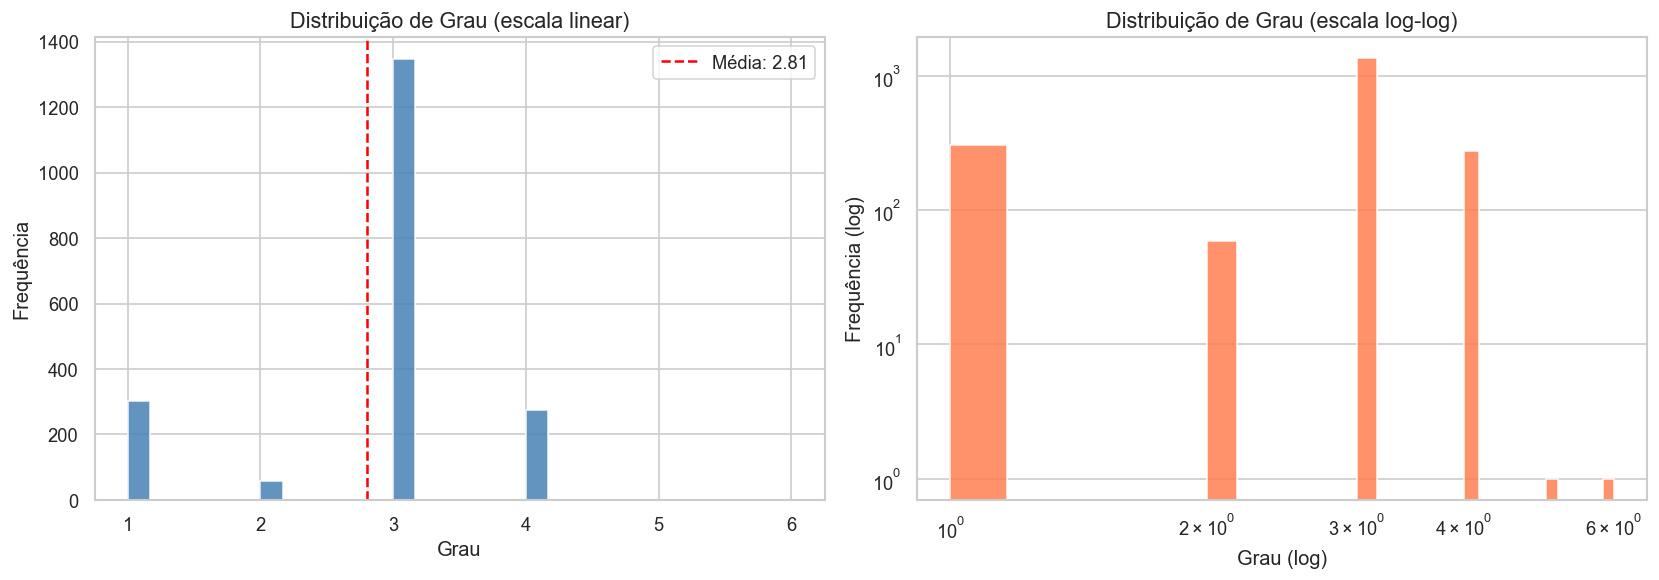

Gráfico salvo como 'distribuicao_grau.png'


In [7]:
# ── Histogramas de distribuição de grau ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala linear
axes[0].hist(degrees, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribuição de Grau (escala linear)', fontsize=13)
axes[0].set_xlabel('Grau')
axes[0].set_ylabel('Frequência')
axes[0].axvline(np.mean(degrees), color='red', linestyle='--',
                label=f'Média: {np.mean(degrees):.2f}')
axes[0].legend()

# Escala log-log
axes[1].hist(degrees, bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].set_title('Distribuição de Grau (escala log-log)', fontsize=13)
axes[1].set_xlabel('Grau (log)')
axes[1].set_ylabel('Frequência (log)')

plt.tight_layout()
plt.savefig('distribuicao_grau.png', bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'distribuicao_grau.png'")

## 4. Betweenness Centrality

Mede a proporção de caminhos mais curtos que passam por cada nó.
Nós com alto betweenness funcionam como **pontes críticas** no fluxo de tráfego.

> **Nota:** calculado com aproximação `k=500` (25% dos nós como pivôs) para
> desempenho. Para resultado exato, use `k=None` (muito mais lento).

In [9]:
# ── Betweenness Centrality (aproximado) ──────────────────────────────────────
# Calculado sobre o componente gigante para consistência com o Gephi
print("Calculando betweenness centrality (aproximado, usando toda a rede)...")
betweenness = nx.betweenness_centrality(G_giant, normalized=True, seed=42)

top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 nós por betweenness:")
for rank, (node, val) in enumerate(top_betweenness, 1):
    print(f"  {rank:2}. Nó {node} → {val:.6f}")

Calculando betweenness centrality (aproximado, k=500)...

Top 10 nós por betweenness:
   1. Nó 7428327102 → 0.153927
   2. Nó 7410672473 → 0.144247
   3. Nó 7413519201 → 0.135714
   4. Nó 7413476027 → 0.133940
   5. Nó 314993255 → 0.131666
   6. Nó 5233567955 → 0.126074
   7. Nó 7414103395 → 0.123735
   8. Nó 3964720268 → 0.122555
   9. Nó 314993252 → 0.121279
  10. Nó 3964616875 → 0.119586


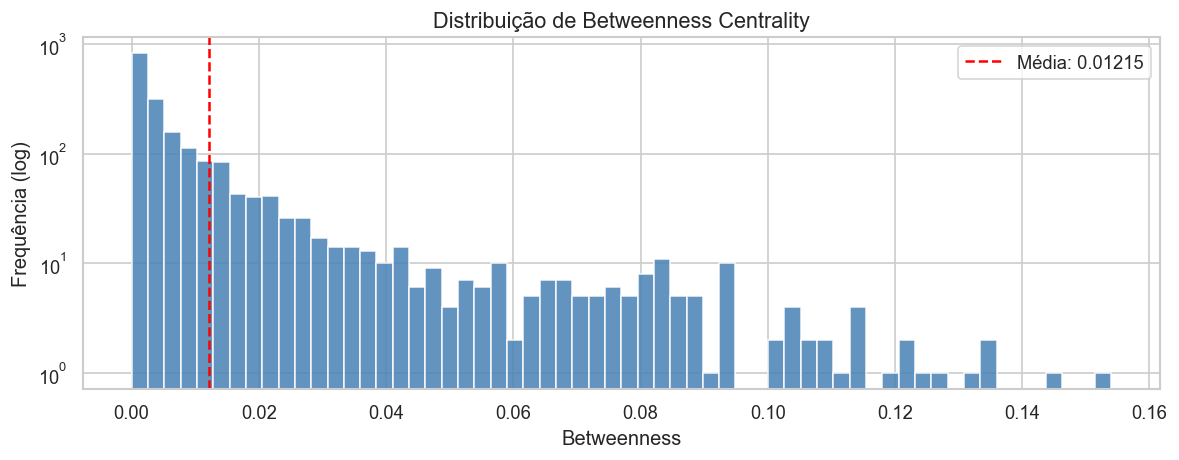

In [10]:
# ── Visualização: histograma de betweenness ───────────────────────────────────
values_bet = list(betweenness.values())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(values_bet, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_yscale('log')
ax.set_title('Distribuição de Betweenness Centrality', fontsize=13)
ax.set_xlabel('Betweenness')
ax.set_ylabel('Frequência (log)')
ax.axvline(np.mean(values_bet), color='red', linestyle='--',
           label=f'Média: {np.mean(values_bet):.5f}')
ax.legend()
plt.tight_layout()
plt.savefig('betweenness_distribuicao.png', bbox_inches='tight')
plt.show()

## 5. Closeness Centrality

Mede quão rapidamente um nó consegue alcançar todos os outros.
Calculado **sobre o componente gigante** para evitar resultados distorcidos
por nós isolados (problema que ocorre ao usar o grafo completo desconexo).

In [11]:
# ── Closeness Centrality ─────────────────────────────────────────────────────
print("Calculando closeness centrality...")
closeness = nx.closeness_centrality(G_giant)

top_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 nós por closeness:")
for rank, (node, val) in enumerate(top_closeness, 1):
    print(f"  {rank:2}. Nó {node} → {val:.6f}")

Calculando closeness centrality...

Top 10 nós por closeness:
   1. Nó 7428327102 → 0.049233
   2. Nó 3964616875 → 0.049055
   3. Nó 7429003086 → 0.048988
   4. Nó 3964655751 → 0.048959
   5. Nó 3964720257 → 0.048878
   6. Nó 7436661174 → 0.048696
   7. Nó 3964720259 → 0.048690
   8. Nó 3964694000 → 0.048628
   9. Nó 314993296 → 0.048534
  10. Nó 7428559181 → 0.048515


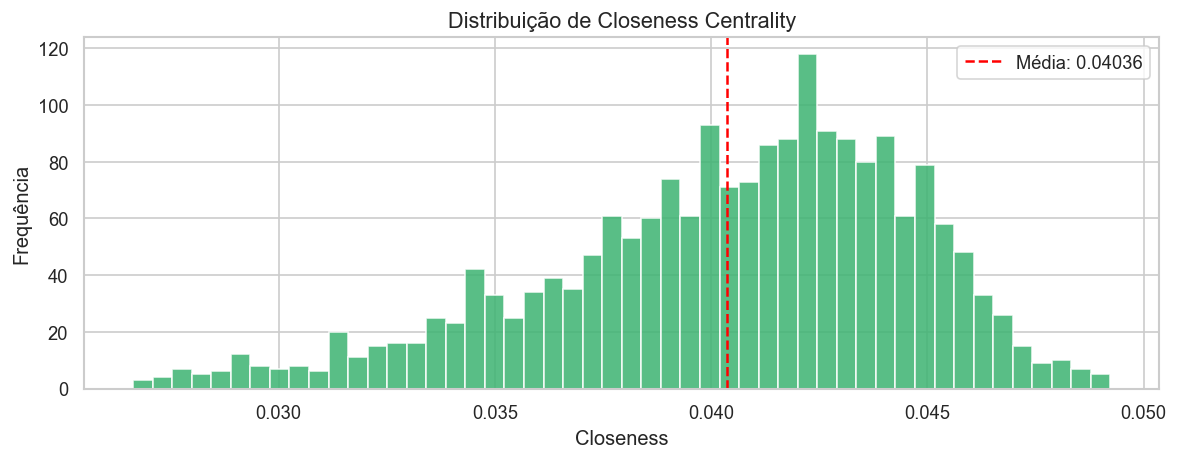

In [12]:
# ── Visualização: histograma de closeness ────────────────────────────────────
values_cl = list(closeness.values())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(values_cl, bins=50, color='mediumseagreen', edgecolor='white', alpha=0.85)
ax.set_title('Distribuição de Closeness Centrality', fontsize=13)
ax.set_xlabel('Closeness')
ax.set_ylabel('Frequência')
ax.axvline(np.mean(values_cl), color='red', linestyle='--',
           label=f'Média: {np.mean(values_cl):.5f}')
ax.legend()
plt.tight_layout()
plt.savefig('closeness_distribuicao.png', bbox_inches='tight')
plt.show()

## 6. K-Core Decomposition

Identifica o **núcleo mais densamente conectado** da rede.
Um nó pertence ao k-core se possui pelo menos *k* vizinhos também no k-core.

In [13]:
# ── K-Core Decomposition ─────────────────────────────────────────────────────
# Calculado sobre o grafo completo não-direcionado
core_number = nx.core_number(G_undirected)
max_core    = max(core_number.values())
k_core_graph = nx.k_core(G_undirected, k=max_core)

print(f"Maior core number (k-max): {max_core}")
print(f"Nós no k-core máximo     : {k_core_graph.number_of_nodes()}")
print(f"Arestas no k-core máximo : {k_core_graph.number_of_edges()}")
print(f"\nDistribuição dos core numbers:")
core_counts = pd.Series(core_number.values()).value_counts().sort_index()
print(core_counts)

Maior core number (k-max): 2
Nós no k-core máximo     : 1643
Arestas no k-core máximo : 2442

Distribuição dos core numbers:
1     341
2    1643
Name: count, dtype: int64


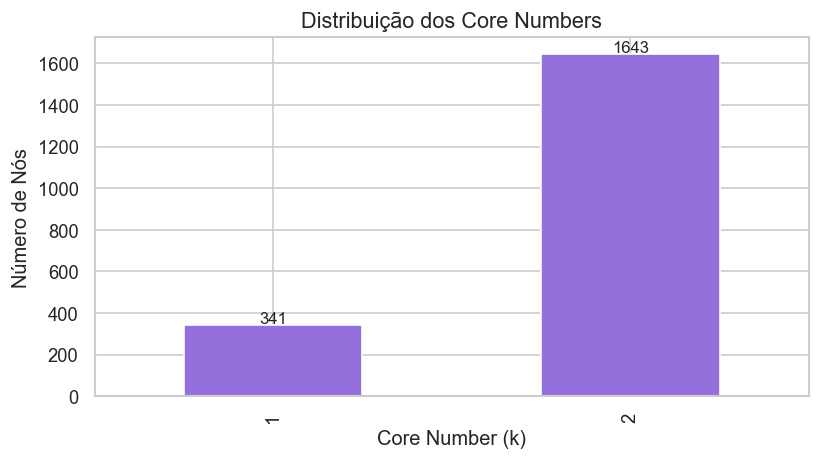

In [14]:
# ── Visualização: distribuição dos core numbers ───────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
core_counts.plot(kind='bar', color='mediumpurple', edgecolor='white', ax=ax)
ax.set_title('Distribuição dos Core Numbers', fontsize=13)
ax.set_xlabel('Core Number (k)')
ax.set_ylabel('Número de Nós')
for i, v in enumerate(core_counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('kcore_distribuicao.png', bbox_inches='tight')
plt.show()

## 7. Exportação para Gephi

Exportamos o grafo completo (`G_undirected`) em formato `.graphml` com:
- `latitude` / `longitude` — para o **Geo Layout** do Gephi
- `degree`, `betweenness`, `closeness`, `core_number` — para colorir/dimensionar nós

> **Atenção:** betweenness e closeness foram calculados sobre o componente gigante.
> Nós fora do componente gigante terão esses valores como `0.0`.

In [15]:
# ── Preparar atributos: preencher métricas para nós fora do componente gigante
# Nós fora do gigante recebem 0.0 nas métricas calculadas sobre ele
betweenness_full = {n: betweenness.get(n, 0.0) for n in G_undirected.nodes()}
closeness_full   = {n: closeness.get(n, 0.0)   for n in G_undirected.nodes()}

nx.set_node_attributes(G_undirected, degree_dict,      "degree")
nx.set_node_attributes(G_undirected, betweenness_full, "betweenness")
nx.set_node_attributes(G_undirected, closeness_full,   "closeness")
nx.set_node_attributes(G_undirected, core_number,      "core_number")

# Renomear x/y → longitude/latitude para o Gephi Geo Layout
for node, data in G_undirected.nodes(data=True):
    if "x" in data:
        data["longitude"] = data["x"]
    if "y" in data:
        data["latitude"]  = data["y"]

# ── Limpeza das arestas (GraphML não suporta geometrias Shapely ou listas) ──
for u, v, data in G_undirected.edges(data=True):
    para_remover   = []
    para_converter = {}
    for key, value in data.items():
        if key == "geometry":
            para_remover.append(key)
        elif isinstance(value, list):
            para_converter[key] = str(value)
        elif value is None:
            para_converter[key] = ""
        elif not isinstance(value, (str, int, float, bool)):
            para_remover.append(key)
    for key in para_remover:
        del data[key]
    data.update(para_converter)

# ── Limpeza dos nós ───────────────────────────────────────────────────────────
PRESERVAR = {"x", "y", "latitude", "longitude"}
for node, data in G_undirected.nodes(data=True):
    para_remover   = []
    para_converter = {}
    for key, value in data.items():
        if key in PRESERVAR:
            continue
        elif isinstance(value, list):
            para_converter[key] = str(value)
        elif value is None:
            para_converter[key] = ""
        elif not isinstance(value, (str, int, float, bool)):
            para_remover.append(key)
    for key in para_remover:
        del data[key]
    data.update(para_converter)

# ── Exportação ────────────────────────────────────────────────────────────────
NOME_ARQUIVO = "Santa-Cruz.graphml"
nx.write_graphml(G_undirected, NOME_ARQUIVO)
print(f"Arquivo '{NOME_ARQUIVO}' exportado com sucesso!")
print(f"  Nós    : {G_undirected.number_of_nodes()}")
print(f"  Arestas: {G_undirected.number_of_edges()}")

# Verificação
amostra_no = list(G_undirected.nodes(data=True))[0]
node_id, node_data = amostra_no
print(f"\nVerificação (nó {node_id}):")
print(f"  latitude  = {node_data.get('latitude',  'NÃO ENCONTRADO')}")
print(f"  longitude = {node_data.get('longitude', 'NÃO ENCONTRADO')}")
print(f"  degree    = {node_data.get('degree',    'NÃO ENCONTRADO')}")
print(f"  betweenness = {node_data.get('betweenness', 'NÃO ENCONTRADO')}")

Arquivo 'Santa-Cruz.graphml' exportado com sucesso!
  Nós    : 1984
  Arestas: 2783

Verificação (nó 314993241):
  latitude  = -6.1964319
  longitude = -36.0763806
  degree    = 1
  betweenness = 0.0


## 8. Resumo dos Resultados

| Métrica | Valor |
|---|---|
| Nós (grafo completo) | 1.984 |
| Arestas (não-direcionado) | 2.783 |
| Componentes conectados | verificar output acima |
| Grau médio | 2,81 |
| Grau máximo | 6 |
| K-core máximo | 2 |
| Nós no k-core máximo | 1.643 |
| Nó mais central (betweenness) | 7428327102 → 0,153 |
| Nó mais acessível (closeness) | 7428327102 → 0,049 |

### Instruções para o Gephi
1. Abra `Santa-Cruz.graphml` no Gephi
2. **Statistics → Connected Components → Run**
3. **Filters → Topology → Giant Component → Filter**
4. **Layout → Geo Layout** (latitude/longitude já exportados)
5. **Appearance → Nodes → Partition → Modularity Class** para colorir comunidades
6. **Statistics → Betweenness/Closeness Centrality** para recalcular no componente gigante
